# Optimization






In [15]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as optim
from scipy.optimize import minimize

## Basic Example

To start, let's try to use the `minimize` function to find the minimum of $f(x) = x^2$

- Examine the documentation below and use the function `f` and initial guess `x0` to assign the solution to the minimization problem to `results` below and print the $x$-coordinate with `print(results.x)`.

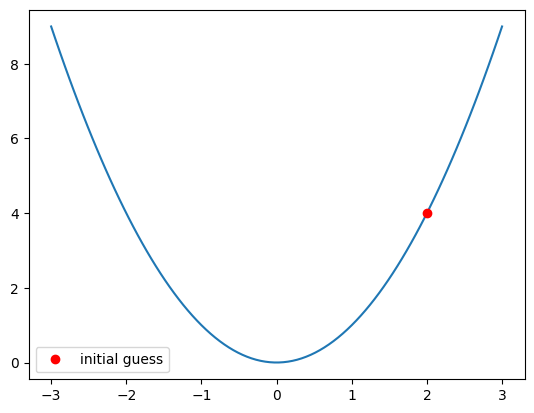

In [37]:
def f(x): return x**2
x0 = 2
x = np.linspace(-3, 3, 100)
plt.plot(x, f(x))
plt.plot(x0, f(x0), 'ro', label = 'initial guess')
plt.legend();

In [38]:
minimize?

In [39]:
results = ''
# print(results.x)

### Am example

A dog daycare feeds the dogs a diet that requires a minimum of 15 grams of fiber, 30 grams of protein.  Each pound of chick peas contains 1 gram of protein, 5 grams of fiber, and 25 grams of fat. Cottage cheese contains 2 grams of protein, 1 gram of fiber, and 14 grams of fat. Suppose that chick peas are priced at 8 USD per pound, and cottage cheese at 6 USD per pound.  The nutritionist claims the dogs will not eat more than 285 grams of fat.   Your goal is to obtain the most economical solution given these constraints.

This is summarized in the table below:

| ingredient | protein | fiber | fat | cost |
| ------ | ------ | ------- | ------- | ------- |
| chick peas | 1 g | 5 g | 25 g | \$8 |
| cottage cheese | 2 g | 1 g | 14 g | \$6 |
| minimum | 15 g | 30 g |  |   |
| maximum |    |     |  285 g |   |

Mathematically, the objective function is:

$$C = 6x + 8y$$

where $x$ = chick peas and $y$ = cottage cheese.  This is the total cost of the combination of chick peas and cottage cheese.

We will save the coefficients as a list for use later.

In [2]:
c = [6, 8]

Because each pound of chick peas contains 1 gram of protein and each cottage cheese 2 grams, and know this needs to combine to at least 15 grams you have:

$$2x + y \geq 15$$

As for cottage cheese, you have:

$$x + 5y \geq 30$$

As for the fat content, you have:

$$14x + 25y \leq 285$$

Further, the amount of $x$ and $y$ must not be negative.

#### Graphical representation

To visualize the solution, you can imagine each of the constraints as a region.  First, functions for these are defined and plotted together.  


In [3]:
def cp(x): #chick peas
    return -2*x + 15
def cc(x): #cottage cheese
    return -1/5*x + 30/5
def fat(x): #fat
    return -14/25*x + 285/25
y = 0
x = np.linspace(0, 30, 100)

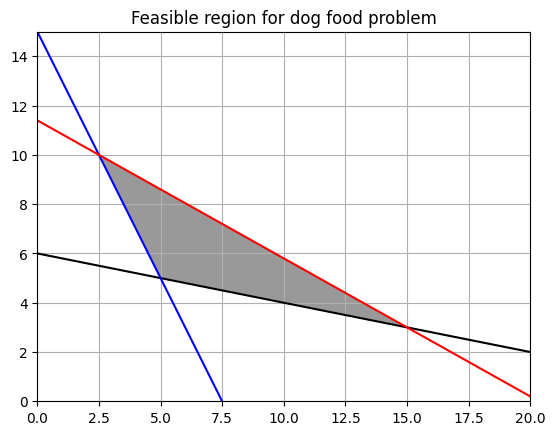

In [4]:
d = np.linspace(0, 30, 1000)
x, y = np.meshgrid(d, d)
plt.imshow((y > cp(x)) & (y < fat(x)) & (y > cc(x)).astype('int'),
           origin = 'lower',
          cmap = 'Greys',
          extent=(x.min(), x.max(), y.min(), y.max()),
          alpha = 0.4)
plt.plot(d, cc(d), '-', color = 'black', label = 'cottage cheese')

plt.plot(d, cp(d), '-', color = 'blue', label = 'chick peas')

plt.plot(d, fat(d), '-', color = 'red', label = 'fat')
plt.ylim(0, 15)
plt.xlim(0, 20)
plt.title('Feasible region for dog food problem')
plt.grid();

The form of all solutions can be found by rewriting the objective function as:

$$y = -\frac{6}{8}x + \frac{C}{8}$$

Below, different values of $C$ are plotted against the original region.  Note that the objective function will obtain its maximum and minimum values at the vertices of the polygon.  Hence, to solve the problem, you need only look to the vertices.  These are highlighted in the plot on the right.

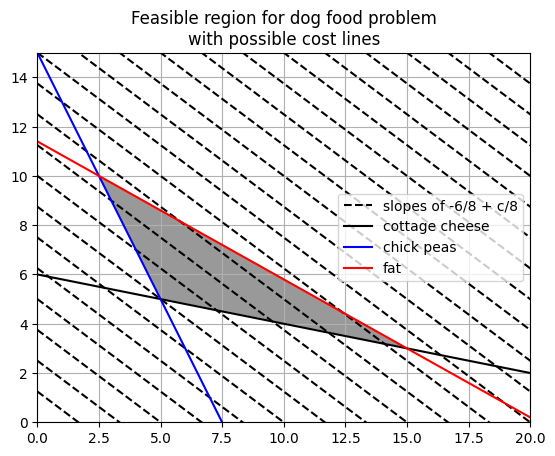

In [35]:
# fig, ax = plt.subplots(1, 2, figsize = (30, 10))
for i in range(10, 1000, 10):
    plt.plot(d, -6/8*d + i/8, '--', color = 'black')
plt.plot(d, -6/8*d + i, '--', color = 'black', label = 'slopes of -6/8 + c/8')
d = np.linspace(0, 30, 1000)
x, y = np.meshgrid(d, d)
plt.imshow((y > cp(x)) & (y < fat(x)) & (y > cc(x)).astype('int'),
           origin = 'lower',
          cmap = 'Greys',
          extent=(x.min(), x.max(), y.min(), y.max()),
          alpha = 0.4)
plt.plot(d, cc(d), '-', color = 'black', label = 'cottage cheese')

plt.plot(d, cp(d), '-', color = 'blue', label = 'chick peas')

plt.plot(d, fat(d), '-', color = 'red', label = 'fat')
plt.ylim(0, 15)
plt.xlim(0, 20)
plt.title('Feasible region for dog food problem\nwith possible cost lines')
plt.grid()
plt.legend();

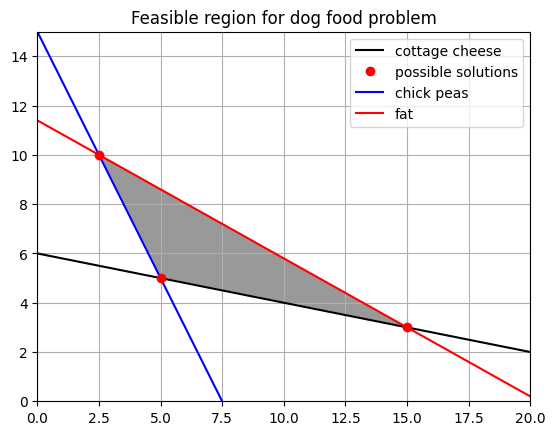

In [6]:
d = np.linspace(0, 30, 1000)
x, y = np.meshgrid(d, d)
plt.imshow((y > cp(x)) & (y < fat(x)) & (y > cc(x)).astype('int'),
           origin = 'lower',
          cmap = 'Greys',
          extent=(x.min(), x.max(), y.min(), y.max()),
          alpha = 0.4)
plt.plot(d, cc(d), '-', color = 'black', label = 'cottage cheese')
plt.plot(15, 3, 'ro', label = 'possible solutions')
plt.plot(d, cp(d), '-', color = 'blue', label = 'chick peas')
plt.plot(d, fat(d), '-', color = 'red', label = 'fat')
plt.ylim(0, 15)
plt.xlim(0, 20)
plt.title('Feasible region for dog food problem')
plt.grid()
plt.plot(5, 5, 'ro')
plt.plot(5/2, 10, 'ro')
plt.legend();

#### using `linprog`

To solve the problem using python, `scipy.optimize` contains the `linprog` function that will solve this problem.  The one exception is that the greater than inequality constraints need to be converted to less thans by multiplying both sides by -1.  

In [7]:
#cost coeffients
c = [6, 8]
#coefficients of less than problems
A = [[-2, -1], [-1, -5], [14, 25]]
#right side of inequalities
b = [-15, -30, 285]
res = optim.linprog(c, A, b)

In [8]:
res

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: 70.0
              x: [ 5.000e+00  5.000e+00]
            nit: 2
          lower:  residual: [ 5.000e+00  5.000e+00]
                 marginals: [ 0.000e+00  0.000e+00]
          upper:  residual: [       inf        inf]
                 marginals: [ 0.000e+00  0.000e+00]
          eqlin:  residual: []
                 marginals: []
        ineqlin:  residual: [ 0.000e+00  0.000e+00  9.000e+01]
                 marginals: [-2.444e+00 -1.111e+00 -0.000e+00]
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip_gap: 0.0

**EXAMPLE**

| PROJECT | $C_0$ | $C_1$ | $C_2$ | NPV at 10% | Profitability Index |
| ------- | ------ | ------- | ------- | -------- | --------- |
| A | -10 | -30 | 5 | 21 | 2.1 |
| B | -5 | 5 | 2 | 16 | 3.2 |
| C | -5 | 5 | 15 | 12 | 2.4 |
| D | 0 | -40 | 60 | 13 | 0.4 |



$$NPV = 21x_A + 16x_B + 12x_C + 13x_D$$

**CONSTRAINTS**

Cash flows for period 0 must not be greater than 10 million.

$$10x_A + 5x_B + 5x_C + 0x_D \leq 10$$

Total outflow in period 1 must not be greater than 10 million.

$$-30x_A - 5x_B - 5x_C + 40x_D \leq 10$$

Finally the amount of the investment must be positive and we cannot purchase more than one of each.

$$0 \leq x_A \leq 1$$
$$0 \leq x_B \leq 1$$
$$0 \leq x_C \leq 1$$
$$0 \leq x_D \leq 1$$

In [27]:
from scipy.optimize import linprog

In [33]:
coefs = [-21, -16, -12, -13]
constr = [[10, 5, 5, 0],
          [-30, -5, -5, 40]]
right_side = [10, 10]
bounds = [(0, 1), (0, 1), (0, 1), (0, 1)]

In [34]:
linprog(coefs, constr, right_side, bounds = bounds)

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: -36.25
              x: [ 5.000e-01  1.000e+00  0.000e+00  7.500e-01]
            nit: 2
          lower:  residual: [ 5.000e-01  1.000e+00  0.000e+00  7.500e-01]
                 marginals: [ 0.000e+00  0.000e+00  1.750e+00  0.000e+00]
          upper:  residual: [ 5.000e-01  0.000e+00  1.000e+00  2.500e-01]
                 marginals: [ 0.000e+00 -2.250e+00  0.000e+00  0.000e+00]
          eqlin:  residual: []
                 marginals: []
        ineqlin:  residual: [ 0.000e+00  0.000e+00]
                 marginals: [-3.075e+00 -3.250e-01]
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip_gap: 0.0